In [127]:
%cd "C:\Users\emann\Documents\GitHub\CodeClarity"

C:\Users\emann\Documents\GitHub\CodeClarity


C:\Users\emann\anaconda3\envs\nst\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Hypothesis

If the evaluation metric is sensitive and reliable, then as we use better backtranslation models, the scores from that metric should increase accordingly. If scores are flat, inconsistent, or noisy across clearly better models, the metric might not be trustworthy

In [128]:
import os
import pandas as pd
from scipy.stats import spearmanr
import numpy as np
import re


In [129]:
metrics = [
    'bertscore_f1',
    'bertscore_precision',
    'bertscore_recall',
    'bleu',
    'chrf++',
    'rougeL',
    'meteor',
    'comet',
    'side'
]


FOLDER = "data/bt_rq_evalScores"

In [130]:
all_dfs = []

for filename in os.listdir(FOLDER):
    if filename.endswith(".csv"):
        file_path = os.path.join(FOLDER, filename)
        try:
            # Remove any of these suffixes: _evalScores.csv, _evalscores.csv, _scores.csv
            bt_model_name = re.sub(r'(_eval[Ss]cores|_scores)\.csv$', '', filename).strip()
            df = pd.read_csv(file_path)

            # Add model name to each row
            df['bt_model'] = bt_model_name

            all_dfs.append(df)
        except Exception as e:
            print(f"Failed to load {filename}: {e}")

df = pd.concat(all_dfs, ignore_index=True)

print("Loaded data shape:", df.shape)
print("Columns in your data:", df.columns.tolist())


Loaded data shape: (6480, 20)
Columns in your data: ['sample_id', 'model_name', 'prompt_used', 'programming_language', 'length_bucket', 'word_len', 'bt_language', 'reference_summary', 'generated_summary', 'backtranslated_summary', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side', 'bt_model']


In [131]:
df['bt_model'].unique()

array(['aya-expanse', 'gemmax2', 'llamax', 'm2m', 'towerinstruct'],
      dtype=object)

In [132]:
df.isna().sum()

sample_id                 0
model_name                0
prompt_used               0
programming_language      0
length_bucket             0
word_len                  0
bt_language               0
reference_summary         0
generated_summary         0
backtranslated_summary    4
bertscore_precision       0
bertscore_recall          0
bertscore_f1              0
bleu                      0
chrf++                    0
rougeL                    0
meteor                    0
comet                     0
side                      0
bt_model                  0
dtype: int64

In [133]:
for col in metrics:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[^\d\.\-eE]', '', regex=True)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [134]:
df.isna().sum()

sample_id                 0
model_name                0
prompt_used               0
programming_language      0
length_bucket             0
word_len                  0
bt_language               0
reference_summary         0
generated_summary         0
backtranslated_summary    4
bertscore_precision       0
bertscore_recall          0
bertscore_f1              0
bleu                      0
chrf++                    0
rougeL                    0
meteor                    0
comet                     0
side                      0
bt_model                  0
dtype: int64

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sample_id               6480 non-null   object 
 1   model_name              6480 non-null   object 
 2   prompt_used             6480 non-null   object 
 3   programming_language    6480 non-null   object 
 4   length_bucket           6480 non-null   object 
 5   word_len                6480 non-null   int64  
 6   bt_language             6480 non-null   object 
 7   reference_summary       6480 non-null   object 
 8   generated_summary       6480 non-null   object 
 9   backtranslated_summary  6476 non-null   object 
 10  bertscore_precision     6480 non-null   float64
 11  bertscore_recall        6480 non-null   float64
 12  bertscore_f1            6480 non-null   float64
 13  bleu                    6480 non-null   float64
 14  chrf++                  6480 non-null   

In [136]:
model_means = df.groupby('bt_model')[metrics].mean()

In [137]:
corr_matrix = model_means.corr(method='spearman')
mean_corr = corr_matrix.apply(lambda row: row.drop(row.name).mean(), axis=1)
reliable_metrics = mean_corr[mean_corr > 0.6].index.tolist()

print("\nReliable Metrics (agree with others):", reliable_metrics)

# --------------------------------
#  STEP 4: Final Model Ranking
# --------------------------------

model_means['aggregated_score'] = model_means[reliable_metrics].mean(axis=1)
final_ranking = model_means['aggregated_score'].sort_values(ascending=False).reset_index()
final_ranking['final_rank'] = final_ranking.index + 1


print("\n=== Inter-Metric Agreement ===")
print(mean_corr.sort_values(ascending=False).to_string())

print("\n=== Final Model Ranking ===")
print(final_ranking[['final_rank', 'bt_model', 'aggregated_score']])


Reliable Metrics (agree with others): ['bertscore_f1', 'bertscore_precision', 'bertscore_recall', 'bleu', 'chrf++', 'rougeL', 'meteor', 'comet', 'side']

=== Inter-Metric Agreement ===
comet                  0.8875
rougeL                 0.8875
bertscore_f1           0.8875
chrf++                 0.8625
bleu                   0.8625
meteor                 0.8625
side                   0.7875
bertscore_recall       0.7750
bertscore_precision    0.6625

=== Final Model Ranking ===
   final_rank       bt_model  aggregated_score
0           1    aya-expanse          0.653416
1           2  towerinstruct          0.646383
2           3         llamax          0.645099
3           4        gemmax2          0.426571
4           5            m2m          0.401358


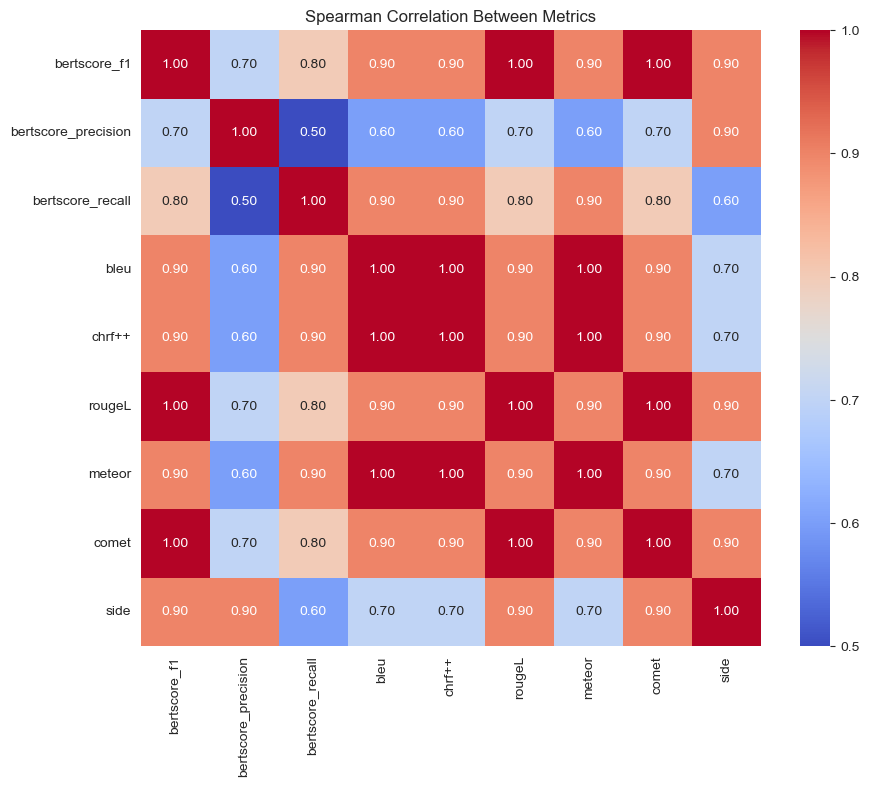

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Between Metrics")
plt.show()


In [139]:
metric_stdevs = model_means[metrics].std().sort_values()
print("\nMetric Stability:")
print(metric_stdevs)



Metric Stability:
bertscore_precision    0.041926
bertscore_f1           0.043855
bertscore_recall       0.049312
bleu                   0.094222
meteor                 0.171234
comet                  0.173993
rougeL                 0.180688
chrf++                 0.182871
side                   0.226839
dtype: float64
